***Integrantes:** Jhoan Avila Gutierrez; Freddy Forero Rojas; Harold Duque Castañeda*<br>
***Clase:** Procesamiento Lenguaje Natural*<br>
***Programa:** Esp. Inteligencia Artificial, Universidad de Cundinamarca*

# 🚀 Laboratorio de Procesamiento de Texto (NLP)

Este notebook contiene la implementación de los conceptos solicitados en la actividad para el procesamiento de texto:

**Primer Bloque:**
1. Normalización de Texto
2. Stemming
3. Stopwords
4. Term Frequency
5. Inverse Document Frequency
6. Part-of-Speech Tagging
7. Lematización
8. Parsing Sintáctico
9. Named-Entity

**Segundo Bloque:**
1. Generacion de texto usando LLM

**Tercer Bloque:**
1. Text Classification
2. Question Answering
3. Summarization
4. Sentence Similarity
5. Translation
6. Text Generation
7. Text mining

## 📦 0. Instalación y Configuración del Entorno
Ejecutar la siguiente celda para instalar y descargar los paquetes necesarios en el ambiente local (`NLTK`, `SpaCy`, `Scikit-Learn`, `Pandas`, etc.).

In [1]:
# Instalación de librerías en Google Colab
!pip install -q nltk spacy scikit-learn pandas gensim matplotlib

import nltk
import spacy
from spacy import displacy
import pandas as pd
import numpy as np
import re
import unicodedata
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Descarga de recursos de NLTK
resources = ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger']
for r in resources:
    try:
        nltk.download(r, quiet=True)
    except Exception as e:
        print(f"Error descargando {r}: {e}")

# Descarga de modelo SpaCy en español
try:
    nlp_es = spacy.load("es_core_news_sm")
except OSError:
    !python -m spacy download es_core_news_sm
    nlp_es = spacy.load("es_core_news_sm")

print("✅ Entorno de NLP configurado exitosamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 35.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 14.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Entorno de NLP configurado exitosamente.


## ⚙️ Configuración Primer Bloque: `Class NLPProcesadorTexto`
1. Ingresamos el texto que sera procesado por cada funcion.
2. Encapsulamos todas las funciones de procesamiento de texto del primer bloque en una clase estructurada.

In [ ]:
texto_a_procesar = """
El grave incendio forestal en Villa de Leyva (Boyacá), iniciado el pasado sábado diecinueve de septiembre
en la vereda La Castellana y el cerro San Marcos, ha consumido más de 1340 hectáreas de vegetación nativa y pino,
afectando gravemente zonas de acuíferos, senderos turísticos y forzando la suspensión temporal de clases.
Las autoridades, que reportan un control del fuego cercano al 78%, sospechan que la emergencia fue provocada
por manos criminales, por lo que la Gobernación de Boyacá ha ofrecido una recompensa de hasta cuarenta y cinco millones
de pesos por información de los responsables mientras los cuerpos de socorro y helicópteros continúan extinguiendo
los focos activos.
"""

class NLPProcesadorTexto:
    def __init__(self, lang="es"):
        self.lang = lang
        nltk_lang = 'spanish' if self.lang == 'es' else 'english'
        self.stemmer = nltk.stem.SnowballStemmer(nltk_lang)
        self.nltk_stopwords = set(nltk.corpus.stopwords.words(nltk_lang))
        model_name = "es_core_news_sm" if self.lang == "es" else "en_core_web_sm"
        self.nlp = spacy.load(model_name)

    # 1. Normalización
    def normalizar_texto(self, texto, remover_acentos=True, remover_numeros=False, minusculas=True):
        if minusculas:
            texto = texto.lower()
        if remover_acentos:
            texto = unicodedata.normalize('NFD', texto)
            texto = ''.join([c for c in texto if unicodedata.category(c) != 'Mn'])
        if remover_numeros:
            texto = re.sub(r'\d+', '', texto)
        texto = re.sub(r'[^\w\s]', '', texto)
        return re.sub(r'\s+', ' ', texto).strip()

    # 2. Stemming
    def stemming_texto(self, tokens):
        if isinstance(tokens, str):
            tokens = re.findall(r'\b\w+\b', tokens)
        return [(t, self.stemmer.stem(t)) for t in tokens]

    # 3. Stopwords
    def remover_stopwords(self, tokens, adicionales=None):
        stops = set(self.nltk_stopwords).union(self.nlp.Defaults.stop_words)
        if adicionales:
            stops.update([a.lower() for a in adicionales])
        return [t for t in tokens if t.lower() not in stops and len(t) > 1]

    # 4. Term Frequency (TF)
    def calcular_tf(self, corpus):
        vectorizer = CountVectorizer()
        matriz = vectorizer.fit_transform(corpus)
        return pd.DataFrame(matriz.toarray(), columns=vectorizer.get_feature_names_out(), index=[f'Texto_{i+1}' for i in range(len(corpus))])

    # 5. TF-IDF & IDF
    def calcular_tfidf(self, corpus):
        vectorizer = TfidfVectorizer()
        matriz = vectorizer.fit_transform(corpus)
        df_tfidf = pd.DataFrame(matriz.toarray(), columns=vectorizer.get_feature_names_out(), index=[f'Texto_{i+1}' for i in range(len(corpus))])
        df_idf = pd.DataFrame({'Palabra': vectorizer.get_feature_names_out(), 'IDF': vectorizer.idf_}).sort_values('IDF', ascending=False)
        return df_tfidf, df_idf

    # 6. POS Tagging
    def etiquetar_pos(self, texto):
        doc = self.nlp(texto)
        return pd.DataFrame([{'Token': t.text, 'POS': t.pos_, 'Tag': t.tag_, 'Explicacion': spacy.explain(t.pos_)} for t in doc if not t.is_space])

    # 7. Lematización
    def lematizar(self, texto):
        doc = self.nlp(texto)
        return pd.DataFrame([{'Token': t.text, 'Lema': t.lemma_, 'POS': t.pos_} for t in doc if not t.is_space and not t.is_punct])

    # 8. Parsing Sintáctico
    def parsing_sintactico(self, texto):
        doc = self.nlp(texto)
        return pd.DataFrame([{'Token': t.text, 'Dep': t.dep_, 'Explicacion': spacy.explain(t.dep_), 'Head': t.head.text} for t in doc if not t.is_space])

    def visualizar_parsing(self, texto):
        doc = self.nlp(texto)
        displacy.render(doc, style="dep", jupyter=True, options={"distance": 100, "color": "#0284c7", "bg": "#f8fafc"})

    # 9. NER
    def reconocer_entidades(self, texto):
        doc = self.nlp(texto)
        return pd.DataFrame([{'Entidad': e.text, 'Etiqueta': e.label_, 'Explicacion': spacy.explain(e.label_)} for e in doc.ents])

    def visualizar_ner(self, texto):
        doc = self.nlp(texto)
        displacy.render(doc, style="ent", jupyter=True)

# Instanciamos el procesador en español
nlp = NLPProcesadorTexto(lang="es")
print("✅ Clase NLPProcesadorTexto esta lista para usarse.")

✅ Clase NLPProcesadorTexto esta lista para usarse.


---
## 🛠️ 1. Normalización de Texto
La **normalización** transforma el texto crudo en un formato uniforme y limpio eliminando variaciones tipográficas, signos de puntuación, mayúsculas y acentos.

In [ ]:
#texto_ejemplo = "¡Hola Mundo! Este es un Ejemplo de Normalización (¡con Ácentós y Números 2026!)."
texto_limpio = nlp.normalizar_texto(texto_a_procesar)

print("🔴 Texto Original :", texto_a_procesar)
print("🟢 Texto Normalizado:", texto_limpio)

🔴 Texto Original : 
El grave incendio forestal en Villa de Leyva (Boyacá), iniciado el pasado sábado diecinueve de septiembre 
en la vereda La Castellana y el cerro San Marcos, ha consumido más de 1340 hectáreas de vegetación nativa y pino, 
afectando gravemente zonas de acuíferos, senderos turísticos y forzando la suspensión temporal de clases. 
Las autoridades, que reportan un control del fuego cercano al 78%, sospechan que la emergencia fue provocada 
por manos criminales, por lo que la Gobernación de Boyacá ha ofrecido una recompensa de hasta cuarenta y cinco millones 
de pesos por información de los responsables mientras los cuerpos de socorro y helicópteros continúan extinguiendo 
los focos activos.

🟢 Texto Normalizado: el grave incendio forestal en villa de leyva boyaca iniciado el pasado sabado diecinueve de septiembre en la vereda la castellana y el cerro san marcos ha consumido mas de 1340 hectareas de vegetacion nativa y pino afectando gravemente zonas de acuiferos senderos

---
## 🌾 2. Stemming
El **Stemming** recorta los sufijos de las palabras para obtener la raíz morfológica común (stem). Es un proceso heurístico basado en reglas de sufijo.

In [ ]:
#palabras_ejemplo = ["corriendo", "correrá", "corredor", "jugadores", "jugando", "computadoras", "computación"]

stems = nlp.stemming_texto(texto_a_procesar)
df_stems = pd.DataFrame(stems, columns=["Palabra Original", "Stem (Raíz)"])
display(df_stems)


,Palabra Original,Stem (Raíz)
0,El,el
1,grave,grav
2,incendio,incendi
3,forestal,forestal
4,en,en
...,...,...
102,continúan,continu
103,extinguiendo,extingu
104,los,los
105,focos,foc


---
## 🛑 3. Stopwords (Palabras Vacías)
Las **Stopwords** son palabras altamente frecuentes (artículos, preposiciones, conjunciones) que aportan poco valor semántico en tareas de análisis.

In [ ]:
#frase = ["el", "gato", "está", "durmiendo", "tranquilamente", "sobre", "el", "sofá", "de", "la", "casa"]
sin_stopwords = nlp.remover_stopwords(texto_limpio.split())

print("🔴 Texto Original :", texto_a_procesar)
print("🟢 Texto sin Stopwords:", sin_stopwords)

🔴 Texto Original : 
El grave incendio forestal en Villa de Leyva (Boyacá), iniciado el pasado sábado diecinueve de septiembre 
en la vereda La Castellana y el cerro San Marcos, ha consumido más de 1340 hectáreas de vegetación nativa y pino, 
afectando gravemente zonas de acuíferos, senderos turísticos y forzando la suspensión temporal de clases. 
Las autoridades, que reportan un control del fuego cercano al 78%, sospechan que la emergencia fue provocada 
por manos criminales, por lo que la Gobernación de Boyacá ha ofrecido una recompensa de hasta cuarenta y cinco millones 
de pesos por información de los responsables mientras los cuerpos de socorro y helicópteros continúan extinguiendo 
los focos activos.

🟢 Texto sin Stopwords: ['grave', 'incendio', 'forestal', 'villa', 'leyva', 'boyaca', 'iniciado', 'sabado', 'diecinueve', 'septiembre', 'vereda', 'castellana', 'cerro', 'san', 'marcos', 'consumido', '1340', 'hectareas', 'vegetacion', 'nativa', 'pino', 'afectando', 'gravemente', 'zonas

---
## 📊 4. Term Frequency (TF)
Mide la frecuencia con la que un término o palabra aparece en un conjunto de documentos.

In [ ]:
corpus = [
    texto_a_procesar,
    "El incendio forestal en Villa de Leyva.",
    "La Gobernación de Boyacá ha ofrecido una recompensa."
]

df_tf = nlp.calcular_tf(corpus)
display(df_tf)

,1340,78,activos,acuíferos,afectando,al,autoridades,boyacá,castellana,cercano,...,suspensión,sábado,temporal,turísticos,un,una,vegetación,vereda,villa,zonas
Texto_1,1,1,1,1,1,1,1,2,1,1,...,1,1,1,1,1,1,1,1,1,1
Texto_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Texto_3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


---
## 📈 5. Inverse Document Frequency (IDF / TF-IDF)
El **TF-IDF** penaliza palabras comunes a través de todos los documentos y destaca términos específicos de cada documento.

In [ ]:
df_tfidf, df_idf = nlp.calcular_tfidf(corpus)

print("Matriz TF-IDF")
display(df_tfidf)

print("\n TOP 10 Inverse Document Frequency (Mayor IDF = Términos más raros/específicos)")
df_idf_order = df_idf.sort_values(by="IDF", ascending=True)
display(df_idf_order.head(10))

Matriz TF-IDF


,1340,78,activos,acuíferos,afectando,al,autoridades,boyacá,castellana,cercano,...,suspensión,sábado,temporal,turísticos,un,una,vegetación,vereda,villa,zonas
Texto_1,0.078948,0.078948,0.078948,0.078948,0.078948,0.078948,0.078948,0.120084,0.078948,0.078948,...,0.078948,0.078948,0.078948,0.078948,0.078948,0.060042,0.078948,0.078948,0.060042,0.078948
Texto_2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.389158,0.000000
Texto_3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.362664,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.362664,0.000000,0.000000,0.000000,0.000000



 TOP 10 Inverse Document Frequency (Mayor IDF = Términos más raros/específicos)


,Palabra,IDF
19,de,1.000000
7,boyacá,1.287682
59,recompensa,1.287682
43,leyva,1.287682
72,una,1.287682
52,ofrecido,1.287682
41,la,1.287682
75,villa,1.287682
27,forestal,1.287682
22,el,1.287682


---
## 🏷️ 6. Part-of-Speech (POS) Tagging
El **POS Tagging** clasifica cada palabra en una categoría gramatical (Sustantivo, Verbo, Adjetivo, Adverbio, etc.).

In [ ]:
#texto_pos = "Los talentosos científicos desarrollan innovadores modelos matemáticos velozmente."
df_pos = nlp.etiquetar_pos(texto_a_procesar)
display(df_pos)

,Token,POS,Tag,Explicacion
0,El,DET,DET,determiner
1,grave,ADJ,ADJ,adjective
2,incendio,NOUN,NOUN,noun
3,forestal,ADJ,ADJ,adjective
4,en,ADP,ADP,adposition
...,...,...,...,...
113,extinguiendo,VERB,VERB,verb
114,los,DET,DET,determiner
115,focos,NOUN,NOUN,noun
116,activos,ADJ,ADJ,adjective


---
## 🌿 7. Lematización
A diferencia del Stemming, la **Lematización** encuentra la forma gramatical canónica de una palabra (lema) utilizando vocabularios y análisis morfológico.

In [ ]:
#texto_lem = "Los gatos estaban corriendo rápidamente y rompieron los jarrones de la mesa."
df_lem = nlp.lematizar(texto_a_procesar)
display(df_lem)

,Token,Lema,POS
0,El,el,DET
1,grave,grave,ADJ
2,incendio,incendio,NOUN
3,forestal,forestal,ADJ
4,en,en,ADP
...,...,...,...
102,continúan,continuar,VERB
103,extinguiendo,extinguir,VERB
104,los,el,DET
105,focos,foco,NOUN


---
## 🌳 8. Parsing (Dependency Parsing)
El **Parsing** analiza las relaciones sintácticas en la oración identificando el verbo principal (raíz), sujeto, objeto directo y modificadores dependientes.

In [ ]:
texto_parse = "El grave incendio forestal en Villa de Leyva iniciado el pasado sábado diecinueve de septiembre ha consumido más de 1340 hectáreas de vegetación nativa y pino"

# 1. Tabla de dependencias
df_parse = nlp.parsing_sintactico(texto_a_procesar)
display(df_parse)

# 2. Visualización interactiva con displaCy
print("\n--- Visualización Parsing del Árbol Sintáctico ---")
nlp.visualizar_parsing(texto_parse)

,Token,Dep,Explicacion,Head
0,El,det,determiner,incendio
1,grave,amod,adjectival modifier,incendio
2,incendio,nsubj,nominal subject,consumido
3,forestal,amod,adjectival modifier,incendio
4,en,case,case marking,Villa
...,...,...,...,...
113,extinguiendo,xcomp,open clausal complement,continúan
114,los,det,determiner,focos
115,focos,obj,object,extinguiendo
116,activos,amod,adjectival modifier,focos



--- Visualización Parsing del Árbol Sintáctico ---


---
## 🔍 9. Named-Entity Recognition (NER)
**NER** reconoce e identifica entidades nombradas en el texto (Personas, Organizaciones, Lugares, Fechas, Monedas, etc.).

In [ ]:
texto_ner = "El grave incendio forestal en Villa de Leyva (Boyaca) iniciado el pasado sábado diecinueve de septiembre ha consumido más de 1340 hectáreas de vegetación nativa y pino. Reporta BBC Noticias."

# 1. Tabla de Entidades
df_ner = nlp.reconocer_entidades(texto_a_procesar)
display(df_ner)

# 2. Visualización destacada con displaCy
print("\n--- Visualización de Entidades Nombradas (NER) ---")
nlp.visualizar_ner(texto_ner)

,Entidad,Etiqueta,Explicacion
0,Villa de Leyva,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
1,Boyacá,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
2,La Castellana,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
3,cerro San Marcos,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
4,Gobernación de Boyacá,LOC,"Non-GPE locations, mountain ranges, bodies of ..."



--- Visualización de Entidades Nombradas (NER) ---


---
## ⚙️ Segundo Bloque: `Large language Models`

## 🏆 9. Generación de texto usando LLM
## Objetivo

Desarrollar un sistema de generación de texto utilizando un modelo
de lenguaje grande (LLM) mediante una API en la nube, aplicando
principios básicos de MLOps para el manejo de datos, consumo del
modelo, registro de resultados y monitoreo.

## Flujo del proyecto

1. Preparación y manejo de datos.
2. Configuración del entorno.
3. Conexión con un LLM mediante API.
4. Generación de texto.
5. Registro de resultados.
6. Monitoreo del sistema.
7. Evaluación de resultados.

In [ ]:
# Instalación de dependencias

!pip install -q openai pandas matplotlib seaborn

In [ ]:
# Importación de librerías

import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from openai import OpenAI

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [ ]:
# Crear dataset de prompts

datos = {
    "id": [1, 2, 3, 4, 5],
    "categoria": [
        "tecnologia",
        "educacion",
        "turismo",
        "salud",
        "medio_ambiente"
    ],
    "prompt": [
        "Explica qué es la inteligencia artificial en palabras sencillas.",
        "Explica por qué es importante aprender programación.",
        "Describe tres lugares turísticos interesantes de Colombia.",
        "Explica de forma general la importancia de dormir bien.",
        "Explica tres formas de reducir la contaminación ambiental."
    ]
}

df = pd.DataFrame(datos)

print("Dataset creado correctamente.")
df

Dataset creado correctamente.


,id,categoria,prompt
0,1,tecnologia,Explica qué es la inteligencia artificial en p...
1,2,educacion,Explica por qué es importante aprender program...
2,3,turismo,Describe tres lugares turísticos interesantes ...
3,4,salud,Explica de forma general la importancia de dor...
4,5,medio_ambiente,Explica tres formas de reducir la contaminació...


In [ ]:
# Revisión básica del dataset

print("Número de registros:", len(df))
print("\nValores nulos:")
print(df.isnull().sum())

print("\nRegistros duplicados:", df.duplicated().sum())

print("\nTipos de datos:")
print(df.dtypes)

Número de registros: 5

Valores nulos:
id           0
categoria    0
prompt       0
dtype: int64

Registros duplicados: 0

Tipos de datos:
id            int64
categoria    object
prompt       object
dtype: object


In [ ]:
# Guardar dataset original

df.to_csv("dataset_prompts.csv", index=False)

print("Dataset guardado como dataset_prompts.csv")

Dataset guardado como dataset_prompts.csv


In [ ]:
!pip install -q google-genai

In [ ]:
from google.colab import userdata
from google import genai

# Obtener API Key de forma segura
gemini_api_key = userdata.get("GEMINI_API_KEY")

if gemini_api_key:
    print("API Key de Gemini cargada correctamente.")
else:
    print("No se encontró la API Key.")

API Key de Gemini cargada correctamente.


In [ ]:
# Crear cliente de Gemini
client = genai.Client(api_key=gemini_api_key)

print("Cliente de Gemini configurado correctamente.")

Cliente de Gemini configurado correctamente.


In [ ]:
# Consultar modelos disponibles

modelos_disponibles = []

for model in client.models.list():
    if "generateContent" in model.supported_actions:
        modelos_disponibles.append(model.name)

print("Modelos disponibles para generación de texto:\n")

for modelo in modelos_disponibles:
    print(modelo)

Modelos disponibles para generación de texto:

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-

In [ ]:
# Primera generación de texto con Gemini 3.8 Flash

prompt = df.loc[0, "prompt"]

response = client.models.generate_content(
    model="gemini-3.8-flash",
    contents=prompt
)

respuesta = response.text

print("PROMPT:")
print(prompt)

print("\nRESPUESTA DEL MODELO:")
print(respuesta)

PROMPT:
Explica qué es la inteligencia artificial en palabras sencillas.

RESPUESTA DEL MODELO:
La **Inteligencia Artificial (IA)** es, en palabras muy sencillas, **hacer que las computadoras puedan pensar y aprender de forma parecida a los humanos**. 

Normalmente, una computadora solo hace exactamente lo que tú le ordenas paso a paso. Pero con la IA, la computadora puede:
* Aprender de sus errores.
* Reconocer patrones (como caras o voces).
* Tomar decisiones por sí misma.
* Resolver problemas nuevos.

### ¿Cómo funciona? (El ejemplo del niño y el gato)
Imagina cómo aprende un niño pequeño a reconocer a un gato. No le das un manual con instrucciones matemáticas; simplemente le señalas gatos en la calle o en libros y le dices: *"Eso es un gato"*. Después de ver muchos gatos diferentes (blancos, negros, grandes, pequeños), el cerebro del niño aprende el patrón y ya sabe qué es un gato.

La Inteligencia Artificial hace exactamente lo mismo: **aprende con ejemplos**. Le muestras millones

In [ ]:
import time

def generar_respuesta(prompt, max_intentos=3):
    """
    Genera una respuesta utilizando Gemini 3.8 Flash.
    Incluye reintentos y medición del tiempo de respuesta.
    """

    for intento in range(1, max_intentos + 1):

        inicio = time.time()

        try:
            response = client.models.generate_content(
                model="gemini-3.8-flash",
                contents=prompt
            )

            tiempo_respuesta = time.time() - inicio

            return {
                "respuesta": response.text,
                "tiempo_segundos": round(tiempo_respuesta, 2),
                "intentos": intento,
                "estado": "exitoso",
                "error": None
            }

        except Exception as e:

            tiempo_respuesta = time.time() - inicio

            print(f"Intento {intento} fallido: {e}")

            if intento < max_intentos:
                # Esperar antes de volver a intentar
                tiempo_espera = 2 ** intento
                print(f"Reintentando en {tiempo_espera} segundos...")
                time.sleep(tiempo_espera)

            else:
                return {
                    "respuesta": None,
                    "tiempo_segundos": round(tiempo_respuesta, 2),
                    "intentos": intento,
                    "estado": "fallido",
                    "error": str(e)
                }

In [ ]:
resultado = generar_respuesta(
    "Explica brevemente qué es el aprendizaje automático."
)

print("Estado:", resultado["estado"])
print("Tiempo:", resultado["tiempo_segundos"], "segundos")
print("Intentos:", resultado["intentos"])

print("\nRespuesta:")
print(resultado["respuesta"])

Estado: exitoso
Tiempo: 4.14 segundos
Intentos: 1

Respuesta:
El **aprendizaje automático** (o *machine learning*) es una rama de la inteligencia artificial que permite a las computadoras **aprender y mejorar por sí mismas a partir de datos**, sin necesidad de ser programadas explícitamente para cada tarea.

En lugar de seguir reglas fijas escritas por un humano, el sistema analiza grandes cantidades de información, identifica patrones y aprende a hacer predicciones o tomar decisiones por su cuenta (como cuando Netflix te recomienda una película, tu correo detecta el spam o tu móvil reconoce tu cara). Cuantos más datos procesa, más preciso se vuelve.


In [ ]:
# Procesar todos los prompts del dataset

resultados = []

for _, fila in df.iterrows():

    print(f"Procesando registro {fila['id']}...")

    resultado = generar_respuesta(fila["prompt"])

    resultados.append({
        "id": fila["id"],
        "categoria": fila["categoria"],
        "prompt": fila["prompt"],
        "respuesta": resultado["respuesta"],
        "tiempo_segundos": resultado["tiempo_segundos"],
        "intentos": resultado["intentos"],
        "estado": resultado["estado"],
        "error": resultado["error"]
    })

print("\nProcesamiento terminado.")

Procesando registro 1...
Intento 1 fallido: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Reintentando en 2 segundos...
Procesando registro 2...
Procesando registro 3...
Intento 1 fallido: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Reintentando en 2 segundos...
Procesando registro 4...
Procesando registro 5...

Procesamiento terminado.


In [ ]:
# Crear DataFrame con los resultados

df_resultados = pd.DataFrame(resultados)

df_resultados

,id,categoria,prompt,respuesta,tiempo_segundos,intentos,estado,error
0,1,tecnologia,Explica qué es la inteligencia artificial en p...,"La **Inteligencia Artificial (IA)** es, en poc...",6.15,2,exitoso,None
1,2,educacion,Explica por qué es importante aprender program...,Aprender programación hoy en día se ha compara...,8.34,1,exitoso,None
2,3,turismo,Describe tres lugares turísticos interesantes ...,Colombia es un país de una biodiversidad y riq...,7.71,2,exitoso,None
3,4,salud,Explica de forma general la importancia de dor...,Dormir bien es uno de los pilares fundamentale...,6.59,1,exitoso,None
4,5,medio_ambiente,Explica tres formas de reducir la contaminació...,Reducir la contaminación ambiental es fundamen...,5.83,1,exitoso,None


In [ ]:
# Resumen de ejecución

print("Total de solicitudes:", len(df_resultados))

print("\nEstados:")
print(df_resultados["estado"].value_counts())

print("\nTiempo promedio:")
print(round(df_resultados["tiempo_segundos"].mean(), 2), "segundos")

print("\nNúmero total de intentos:")
print(df_resultados["intentos"].sum())

Total de solicitudes: 5

Estados:
estado
exitoso    5
Name: count, dtype: int64

Tiempo promedio:
6.92 segundos

Número total de intentos:
7


In [ ]:
# Guardar registro de ejecuciones

df_resultados.to_csv("registro_ejecuciones.csv", index=False)

print("Registro guardado como registro_ejecuciones.csv")

Registro guardado como registro_ejecuciones.csv


In [ ]:
# Monitoreo: estado de las solicitudes

estados = df_resultados["estado"].value_counts()

print("Resumen de solicitudes:")
print(estados)

print("\nPorcentaje de éxito:")

exitosas = (df_resultados["estado"] == "exitoso").sum()
total = len(df_resultados)

porcentaje_exito = (exitosas / total) * 100

print(f"{porcentaje_exito:.2f}%")

Resumen de solicitudes:
estado
exitoso    5
Name: count, dtype: int64

Porcentaje de éxito:
100.00%


In [ ]:
# Estadísticas de tiempo de respuesta

print("Tiempo mínimo:",
      df_resultados["tiempo_segundos"].min(), "segundos")

print("Tiempo máximo:",
      df_resultados["tiempo_segundos"].max(), "segundos")

print("Tiempo promedio:",
      round(df_resultados["tiempo_segundos"].mean(), 2), "segundos")

Tiempo mínimo: 5.83 segundos
Tiempo máximo: 8.34 segundos
Tiempo promedio: 6.92 segundos


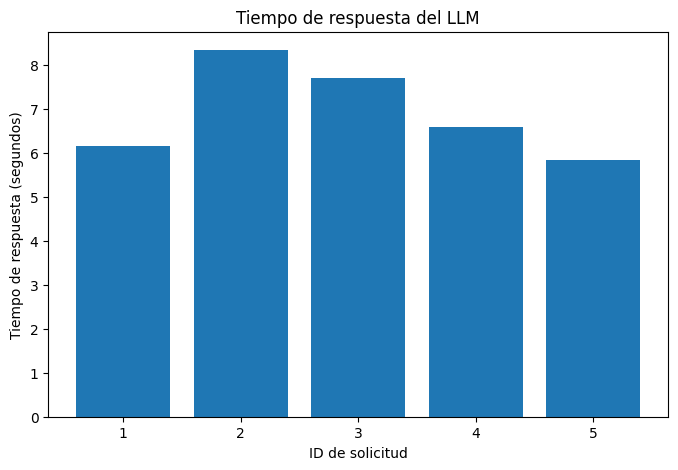

In [ ]:
# Gráfica de tiempos de respuesta

plt.figure(figsize=(8, 5))

plt.bar(
    df_resultados["id"],
    df_resultados["tiempo_segundos"]
)

plt.xlabel("ID de solicitud")
plt.ylabel("Tiempo de respuesta (segundos)")
plt.title("Tiempo de respuesta del LLM")

plt.show()

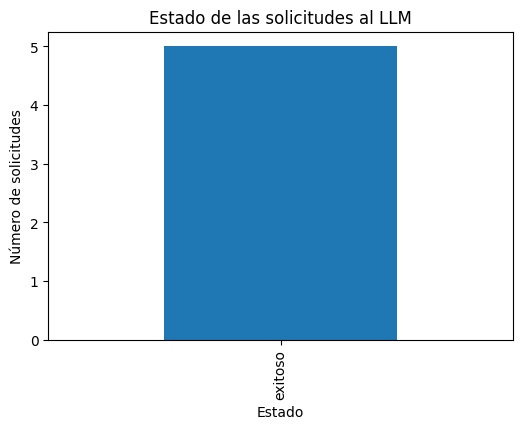

In [ ]:
# Gráfica de solicitudes por estado

plt.figure(figsize=(6, 4))

df_resultados["estado"].value_counts().plot(kind="bar")

plt.xlabel("Estado")
plt.ylabel("Número de solicitudes")
plt.title("Estado de las solicitudes al LLM")

plt.show()

In [ ]:
# Evaluación básica de las respuestas

def evaluar_respuesta(respuesta):
    if respuesta is None:
        return {
            "longitud_caracteres": 0,
            "numero_palabras": 0,
            "respuesta_valida": False
        }

    numero_palabras = len(respuesta.split())
    longitud_caracteres = len(respuesta)

    return {
        "longitud_caracteres": longitud_caracteres,
        "numero_palabras": numero_palabras,
        "respuesta_valida": numero_palabras >= 10
    }

In [ ]:
# Aplicar evaluación a todas las respuestas

metricas = df_resultados["respuesta"].apply(evaluar_respuesta)

df_metricas = pd.DataFrame(metricas.tolist())

df_resultados = pd.concat(
    [df_resultados, df_metricas],
    axis=1
)

df_resultados

,id,categoria,prompt,respuesta,tiempo_segundos,intentos,estado,error,longitud_caracteres,numero_palabras,respuesta_valida
0,1,tecnologia,Explica qué es la inteligencia artificial en p...,"La **Inteligencia Artificial (IA)** es, en poc...",6.15,2,exitoso,None,1800,307,True
1,2,educacion,Explica por qué es importante aprender program...,Aprender programación hoy en día se ha compara...,8.34,1,exitoso,None,3706,565,True
2,3,turismo,Describe tres lugares turísticos interesantes ...,Colombia es un país de una biodiversidad y riq...,7.71,2,exitoso,None,3036,491,True
3,4,salud,Explica de forma general la importancia de dor...,Dormir bien es uno de los pilares fundamentale...,6.59,1,exitoso,None,2809,441,True
4,5,medio_ambiente,Explica tres formas de reducir la contaminació...,Reducir la contaminación ambiental es fundamen...,5.83,1,exitoso,None,2525,381,True


In [ ]:
# Resumen de calidad

print("Promedio de palabras por respuesta:",
      round(df_resultados["numero_palabras"].mean(), 2))

print("Promedio de caracteres por respuesta:",
      round(df_resultados["longitud_caracteres"].mean(), 2))

respuestas_validas = df_resultados["respuesta_valida"].sum()

print(
    f"Respuestas que cumplen el criterio: "
    f"{respuestas_validas}/{len(df_resultados)}"
)

Promedio de palabras por respuesta: 437.0
Promedio de caracteres por respuesta: 2775.2
Respuestas que cumplen el criterio: 5/5


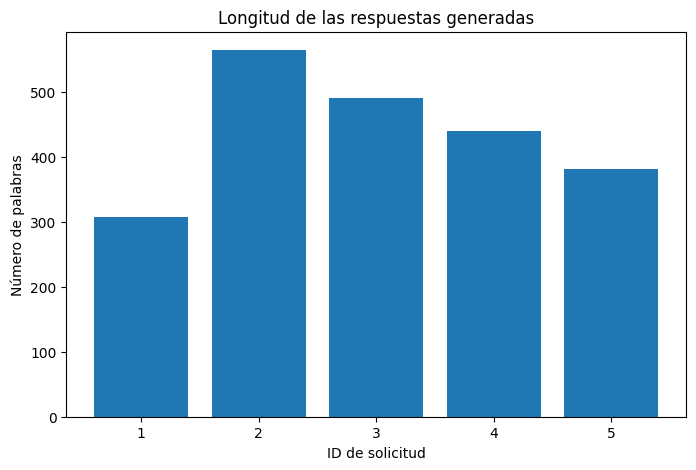

In [ ]:
# Visualización de longitud de respuestas

plt.figure(figsize=(8, 5))

plt.bar(
    df_resultados["id"],
    df_resultados["numero_palabras"]
)

plt.xlabel("ID de solicitud")
plt.ylabel("Número de palabras")
plt.title("Longitud de las respuestas generadas")

plt.show()

In [ ]:
# Guardar resultados finales

df_resultados.to_csv(
    "resultados_finales_llm.csv",
    index=False
)

print("Resultados guardados correctamente.")
print("Archivo: resultados_finales_llm.csv")

Resultados guardados correctamente.
Archivo: resultados_finales_llm.csv


In [ ]:
# Resumen final del experimento

total_solicitudes = len(df_resultados)

solicitudes_exitosas = (
    df_resultados["estado"] == "exitoso"
).sum()

porcentaje_exito = (
    solicitudes_exitosas / total_solicitudes
) * 100

tiempo_promedio = df_resultados[
    "tiempo_segundos"
].mean()

palabras_promedio = df_resultados[
    "numero_palabras"
].mean()

print("========== RESUMEN DEL EXPERIMENTO ==========")

print(f"Total de solicitudes: {total_solicitudes}")
print(f"Solicitudes exitosas: {solicitudes_exitosas}")
print(f"Porcentaje de éxito: {porcentaje_exito:.2f}%")
print(f"Tiempo promedio: {tiempo_promedio:.2f} segundos")
print(f"Palabras promedio por respuesta: {palabras_promedio:.2f}")

print("==============================================")

========== RESUMEN DEL EXPERIMENTO ==========
Total de solicitudes: 5
Solicitudes exitosas: 5
Porcentaje de éxito: 100.00%
Tiempo promedio: 6.92 segundos
Palabras promedio por respuesta: 437.00


# Arquitectura del proyecto

El proyecto utiliza Google Colab como entorno de ejecución y un
modelo LLM alojado en la nube mediante una API.

### Flujo del sistema

Usuario / Dataset
       ↓
Google Colab
       ↓
Validación y procesamiento de datos
       ↓
API de Gemini
       ↓
Gemini 3.8 Flash
       ↓
Generación de texto
       ↓
Registro de resultados
       ↓
Monitoreo y evaluación

### Componentes MLOps

- **Datos:** dataset de prompts almacenado en CSV.
- **Modelo:** Gemini 3.8 Flash mediante API.
- **Infraestructura:** Google Colab + servicio de IA en la nube.
- **Registro:** prompts, respuestas, tiempos, estados e intentos.
- **Monitoreo:** porcentaje de éxito y tiempo de respuesta.
- **Evaluación:** longitud y cantidad de palabras de las respuestas.

# Conclusiones

Durante esta práctica se desarrolló un sistema de generación de texto
utilizando un modelo de lenguaje grande (LLM) mediante una API en la nube.

Se realizó un manejo básico de los datos mediante un dataset de prompts,
validando registros y almacenándolos en formato CSV.

El modelo Gemini 3.8 Flash fue utilizado como servicio en la nube,
permitiendo generar respuestas sin ejecutar el modelo localmente.

También se implementó un registro de las ejecuciones, incluyendo el
tiempo de respuesta, número de intentos, estado de la solicitud y
posibles errores.

Finalmente, se implementaron métricas y visualizaciones para monitorear
el funcionamiento del sistema y evaluar características básicas de las
respuestas generadas.

La práctica permitió aplicar conceptos básicos de MLOps a un sistema
basado en LLM, integrando datos, modelo, infraestructura, monitoreo y
evaluación.

---
## ⚙️ Tercer bloque: YouTube Statistics

Este bloque aplica las técnicas de la semana 6 a comentarios reales y construye un modelo experimental que estima el desempeño de cada video.

## 📦 Descarga y configuración

Los datos se descargan automáticamente desde Kaggle. Los modelos públicos de Hugging Face se ejecutan dentro de Colab y no requieren claves privadas.

In [2]:
!pip install -q kagglehub transformers sentencepiece sacremoses gradio

import json
import joblib
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datetime import datetime, timezone
from pathlib import Path

ruta_dataset = Path(
    kagglehub.dataset_download("advaypatil/youtube-statistics")
)

print("Dataset descargado en:", ruta_dataset)
print("Archivos:", [archivo.name for archivo in ruta_dataset.iterdir()])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 4.2 MB/s eta 0:00:00


100%|██████████| 1.64M/1.64M [00:00<00:00, 2.13MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/advaypatil/youtube-statistics/versions/1
Archivos: ['videos-stats.csv', 'comments.csv']


## 📊 Exploración inicial del conjunto de datos

In [3]:
ruta_videos = ruta_dataset / "videos-stats.csv"
ruta_comentarios = ruta_dataset / "comments.csv"

df_videos = pd.read_csv(ruta_videos)
df_comentarios = pd.read_csv(ruta_comentarios)

print("Dimensión de videos:", df_videos.shape)
print("Dimensión de comentarios:", df_comentarios.shape)
print("\nColumnas de videos:", df_videos.columns.tolist())
print("Columnas de comentarios:", df_comentarios.columns.tolist())
display(df_videos.head())
display(df_comentarios.head())

Dimensión de videos: (1881, 8)
Dimensión de comentarios: (18409, 5)

Columnas de videos: ['Unnamed: 0', 'Title', 'Video ID', 'Published At', 'Keyword', 'Likes', 'Comments', 'Views']
Columnas de comentarios: ['Unnamed: 0', 'Video ID', 'Comment', 'Likes', 'Sentiment']


,Unnamed: 0,Title,Video ID,Published At,Keyword,Likes,Comments,Views
0,0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,2022-08-23,tech,3407.0,672.0,135612.0
1,1,The most EXPENSIVE thing I own.,b3x28s61q3c,2022-08-24,tech,76779.0,4306.0,1758063.0
2,2,My New House Gaming Setup is SICK!,4mgePWWCAmA,2022-08-23,tech,63825.0,3338.0,1564007.0
3,3,Petrol Vs Liquid Nitrogen | Freezing Experimen...,kXiYSI7H2b0,2022-08-23,tech,71566.0,1426.0,922918.0
4,4,Best Back to School Tech 2022!,ErMwWXQxHp0,2022-08-08,tech,96513.0,5155.0,1855644.0


,Unnamed: 0,Video ID,Comment,Likes,Sentiment
0,0,wAZZ-UWGVHI,Let's not forget that Apple Pay in 2014 requir...,95.0,1.0
1,1,wAZZ-UWGVHI,Here in NZ 50% of retailers don’t even have co...,19.0,0.0
2,2,wAZZ-UWGVHI,I will forever acknowledge this channel with t...,161.0,2.0
3,3,wAZZ-UWGVHI,Whenever I go to a place that doesn’t take App...,8.0,0.0
4,4,wAZZ-UWGVHI,"Apple Pay is so convenient, secure, and easy t...",34.0,2.0


## 🧹 Preparación y limpieza de los datos

In [4]:
videos_limpios = df_videos.drop(columns=["Unnamed: 0"], errors="ignore").copy()
comentarios_limpios = df_comentarios.drop(columns=["Unnamed: 0"], errors="ignore").copy()

for datos in (videos_limpios, comentarios_limpios):
    datos["Video ID"] = datos["Video ID"].astype("string").str.strip()

comentarios_limpios["Comment"] = comentarios_limpios["Comment"].astype("string").str.strip()

for columna in ["Likes", "Comments", "Views"]:
    videos_limpios[columna] = pd.to_numeric(videos_limpios[columna], errors="coerce")
for columna in ["Likes", "Sentiment"]:
    comentarios_limpios[columna] = pd.to_numeric(comentarios_limpios[columna], errors="coerce")

videos_limpios.dropna(subset=["Video ID", "Views"], inplace=True)
comentarios_limpios.dropna(subset=["Video ID", "Comment", "Sentiment"], inplace=True)
comentarios_limpios = comentarios_limpios[comentarios_limpios["Comment"].str.len() > 0]
videos_limpios.drop_duplicates(subset=["Video ID"], inplace=True)
comentarios_limpios.drop_duplicates(subset=["Video ID", "Comment"], inplace=True)

mapa_sentimientos = {0: "Negativo", 1: "Neutral", 2: "Positivo"}
comentarios_limpios["Sentimiento texto"] = comentarios_limpios["Sentiment"].map(mapa_sentimientos)
comentarios_limpios["Cantidad caracteres"] = comentarios_limpios["Comment"].str.len()
comentarios_limpios["Cantidad palabras"] = comentarios_limpios["Comment"].str.split().str.len()

print("Videos después de la limpieza:", videos_limpios.shape)
print("Comentarios después de la limpieza:", comentarios_limpios.shape)
display(comentarios_limpios["Sentimiento texto"].value_counts().to_frame("Cantidad"))

Videos después de la limpieza: (1867, 7)
Comentarios después de la limpieza: (18159, 7)


,Cantidad
Sentimiento texto,
Positivo,11239
Neutral,4592
Negativo,2328


## 🔗 Integración de comentarios y estadísticas por video

In [5]:
resumen_comentarios = comentarios_limpios.groupby("Video ID").agg(
    Comentarios_disponibles=("Comment", "count"),
    Likes_comentarios_total=("Likes", "sum"),
    Likes_comentarios_promedio=("Likes", "mean"),
    Palabras_promedio=("Cantidad palabras", "mean"),
    Caracteres_promedio=("Cantidad caracteres", "mean"),
    Sentimiento_promedio=("Sentiment", "mean")
).reset_index()

proporciones = pd.crosstab(
    comentarios_limpios["Video ID"],
    comentarios_limpios["Sentimiento texto"],
    normalize="index"
).reset_index()

for sentimiento in ["Negativo", "Neutral", "Positivo"]:
    if sentimiento not in proporciones:
        proporciones[sentimiento] = 0.0

proporciones.rename(columns={
    "Negativo": "Proporcion_negativos",
    "Neutral": "Proporcion_neutrales",
    "Positivo": "Proporcion_positivos"
}, inplace=True)

textos = comentarios_limpios.groupby("Video ID")["Comment"].apply(
    lambda valores: " ".join(valores.astype(str))
).reset_index(name="Texto_comentarios")

resumen_comentarios = resumen_comentarios.merge(
    proporciones[["Video ID", "Proporcion_negativos", "Proporcion_neutrales", "Proporcion_positivos"]],
    on="Video ID"
).merge(textos, on="Video ID")

datos_youtube = videos_limpios.merge(resumen_comentarios, on="Video ID", how="inner")
datos_youtube["Log_Views"] = np.log1p(datos_youtube["Views"])

print("Videos con comentarios asociados:", len(datos_youtube))
display(datos_youtube.head())

Videos con comentarios asociados: 1867


,Title,Video ID,Published At,Keyword,Likes,Comments,Views,Comentarios_disponibles,Likes_comentarios_total,Likes_comentarios_promedio,Palabras_promedio,Caracteres_promedio,Sentimiento_promedio,Proporcion_negativos,Proporcion_neutrales,Proporcion_positivos,Texto_comentarios,Log_Views
0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,2022-08-23,tech,3407.0,672.0,135612.0,10,391.0,39.1,36.6,202.0,1.2,0.2,0.4,0.4,Let's not forget that Apple Pay in 2014 requir...,11.817561
1,The most EXPENSIVE thing I own.,b3x28s61q3c,2022-08-24,tech,76779.0,4306.0,1758063.0,10,5982.0,598.2,44.6,245.4,1.8,0.1,0.0,0.9,"Wow, you really went to town on the PSU test r...",14.379724
2,My New House Gaming Setup is SICK!,4mgePWWCAmA,2022-08-23,tech,63825.0,3338.0,1564007.0,10,6262.0,626.2,29.4,157.9,1.9,0.0,0.1,0.9,Linus!!! Just turn the key lights 180 and bou...,14.262762
3,Petrol Vs Liquid Nitrogen | Freezing Experimen...,kXiYSI7H2b0,2022-08-23,tech,71566.0,1426.0,922918.0,10,5288.0,528.8,12.7,84.0,1.6,0.0,0.4,0.6,Unstoppable experiments with liquid nitrogen 🎉...,13.735297
4,Best Back to School Tech 2022!,ErMwWXQxHp0,2022-08-08,tech,96513.0,5155.0,1855644.0,10,27217.0,2721.7,77.3,418.0,1.6,0.0,0.4,0.6,"Guys, a quick note that you do NOT need all th...",14.433743


## ❓ 11. Question Answering

El sistema extrae una respuesta desde los comentarios con mayor interacción. Como el corpus está principalmente en inglés, se usa un modelo entrenado con preguntas y contextos en ese idioma.

In [6]:
from transformers import AutoModelForQuestionAnswering, AutoModelForSeq2SeqLM, AutoTokenizer

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nombre_modelo_qa = "distilbert-base-cased-distilled-squad"
tokenizador_qa = AutoTokenizer.from_pretrained(nombre_modelo_qa)
modelo_qa = AutoModelForQuestionAnswering.from_pretrained(nombre_modelo_qa).to(dispositivo)
modelo_qa.eval()

print("Modelo QA cargado en:", dispositivo)

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  261MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Modelo QA cargado en: cpu


In [7]:
def responder_pregunta_video(video_id, pregunta, cantidad_comentarios=5):
    registro = datos_youtube[datos_youtube["Video ID"] == video_id]
    comentarios = comentarios_limpios[comentarios_limpios["Video ID"] == video_id].nlargest(
        cantidad_comentarios, "Likes"
    )
    if registro.empty or comentarios.empty:
        return {"Error": "Video o comentarios no disponibles"}

    contexto = " ".join(comentarios["Comment"].astype(str))
    entradas = tokenizador_qa(
        pregunta, contexto, return_tensors="pt", truncation=True, max_length=512
    )
    entradas = {clave: valor.to(dispositivo) for clave, valor in entradas.items()}
    with torch.no_grad():
        salida = modelo_qa(**entradas)

    inicio = int(torch.argmax(salida.start_logits, dim=-1)[0])
    fin = int(torch.argmax(salida.end_logits, dim=-1)[0])
    fin = max(inicio, fin)
    respuesta = tokenizador_qa.decode(
        entradas["input_ids"][0][inicio:fin + 1], skip_special_tokens=True
    )
    confianza = (
        torch.softmax(salida.start_logits, dim=-1)[0, inicio]
        * torch.softmax(salida.end_logits, dim=-1)[0, fin]
    ).item()
    return {
        "Título": registro.iloc[0]["Title"],
        "Pregunta": pregunta,
        "Respuesta": respuesta,
        "Confianza": round(confianza, 4)
    }

video_ejemplo = datos_youtube.iloc[0]
resultado_qa = responder_pregunta_video(
    video_ejemplo["Video ID"], "What do viewers say about Apple Pay?"
)
display(pd.DataFrame([resultado_qa]))

,Título,Pregunta,Respuesta,Confianza
0,Apple Pay Is Killing the Physical Wallet After...,What do viewers say about Apple Pay?,"so convenient, secure, and easy to use",0.3774


## 📝 12. Summarization

Se aplica una estrategia extractiva: TF-IDF representa los comentarios y la similitud coseno permite elegir las opiniones más centrales del conjunto. Así se obtiene un resumen trazable, sin claves API y sin inventar información.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def resumir_comentarios_video(video_id, cantidad_comentarios=10, fragmentos_resumen=3):
    registro = datos_youtube[datos_youtube["Video ID"] == video_id]
    comentarios = comentarios_limpios[
        comentarios_limpios["Video ID"] == video_id
    ].nlargest(cantidad_comentarios, "Likes").copy()

    if registro.empty or comentarios.empty:
        return {"Error": "Video o comentarios no disponibles"}

    textos = comentarios["Comment"].astype(str).tolist()
    if len(textos) == 1:
        seleccionados = [0]
        puntajes = np.array([1.0])
    else:
        vectorizador = TfidfVectorizer(stop_words="english")
        matriz = vectorizador.fit_transform(textos)
        similitudes = cosine_similarity(matriz)
        puntajes = (similitudes.sum(axis=1) - 1) / (len(textos) - 1)
        seleccionados = np.argsort(puntajes)[::-1][:fragmentos_resumen]

    # Limita cada fragmento para producir un resultado legible.
    fragmentos = [
        " ".join(textos[indice].split()[:45])
        for indice in seleccionados
    ]
    resumen = " ".join(fragmentos)

    return {
        "Video ID": video_id,
        "Título": registro.iloc[0]["Title"],
        "Comentarios analizados": len(textos),
        "Fragmentos seleccionados": len(fragmentos),
        "Resumen extractivo": resumen,
        "Centralidad promedio": round(float(np.mean(puntajes[seleccionados])), 4)
    }

resultado_resumen = resumir_comentarios_video(video_ejemplo["Video ID"])
resumen_ejemplo = resultado_resumen.get("Resumen extractivo", "")
display(pd.DataFrame([resultado_resumen]))

,Video ID,Título,Comentarios analizados,Fragmentos seleccionados,Resumen extractivo,Centralidad promedio
0,wAZZ-UWGVHI,Apple Pay Is Killing the Physical Wallet After...,10,3,"For now, I need both Apple Pay and the physica...",0.122


## 🔗 13. Sentence Similarity

Se representa cada comentario con TF-IDF y se calcula la similitud coseno. El resultado permite encontrar opiniones lingüísticamente cercanas.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

def comentarios_mas_similares(video_id, limite=10):
    comentarios = comentarios_limpios[
        comentarios_limpios["Video ID"] == video_id
    ]["Comment"].head(limite).astype(str).tolist()
    if len(comentarios) < 2:
        return pd.DataFrame()
    vectorizador = TfidfVectorizer(stop_words="english")
    vectores = vectorizador.fit_transform(comentarios)
    matriz = cosine_similarity(vectores)
    np.fill_diagonal(matriz, -1)
    i, j = np.unravel_index(np.argmax(matriz), matriz.shape)
    return pd.DataFrame([{
        "Comentario 1": comentarios[i],
        "Comentario 2": comentarios[j],
        "Similitud coseno": round(float(matriz[i, j]), 4)
    }])

display(comentarios_mas_similares(video_ejemplo["Video ID"]))

,Comentario 1,Comentario 2,Similitud coseno
0,"Apple Pay is so convenient, secure, and easy t...","For now, I need both Apple Pay and the physica...",0.4121


## 🏷️ 14. Text Classification

Se entrena un clasificador supervisado de sentimiento con TF-IDF y regresión logística. La evaluación se realiza sobre datos no utilizados durante el entrenamiento.

Accuracy: 0.7271
              precision    recall  f1-score   support

    Negativo       0.48      0.64      0.55       466
     Neutral       0.56      0.66      0.61       918
    Positivo       0.91      0.77      0.83      2248

    accuracy                           0.73      3632
   macro avg       0.65      0.69      0.66      3632
weighted avg       0.76      0.73      0.74      3632



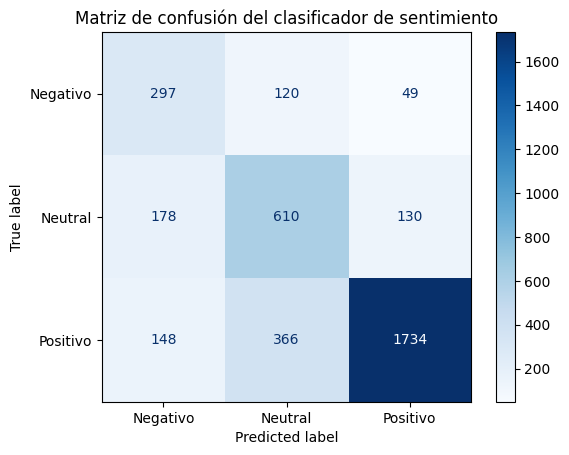

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X = comentarios_limpios["Comment"].astype(str)
y = comentarios_limpios["Sentiment"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

clasificador_sentimiento = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english", max_features=10000, ngram_range=(1, 2), min_df=2
    )),
    ("modelo", LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ))
])

clasificador_sentimiento.fit(X_train, y_train)
predicciones_sentimiento = clasificador_sentimiento.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, predicciones_sentimiento), 4))
print(classification_report(
    y_test,
    predicciones_sentimiento,
    labels=[0, 1, 2],
    target_names=["Negativo", "Neutral", "Positivo"],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_sentimiento,
    labels=[0, 1, 2],
    display_labels=["Negativo", "Neutral", "Positivo"],
    cmap="Blues"
)
plt.title("Matriz de confusión del clasificador de sentimiento")
plt.show()

## 🌐 15. Translation

Se utiliza MarianMT, un modelo público especializado en traducción automática de inglés a español. Su especialización ofrece una salida más estable que un modelo general pequeño.

In [11]:
nombre_modelo_traduccion = "Helsinki-NLP/opus-mt-en-es"
tokenizador_traduccion = AutoTokenizer.from_pretrained(nombre_modelo_traduccion)
modelo_traduccion = AutoModelForSeq2SeqLM.from_pretrained(
    nombre_modelo_traduccion
).to(dispositivo)
modelo_traduccion.eval()

def traducir_al_espanol(texto):
    entradas = tokenizador_traduccion(
        str(texto),
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(dispositivo)
    with torch.no_grad():
        salida = modelo_traduccion.generate(
            **entradas,
            max_new_tokens=256,
            num_beams=4,
            early_stopping=True
        )
    return tokenizador_traduccion.decode(salida[0], skip_special_tokens=True)

comentario_original = comentarios_limpios.iloc[0]["Comment"]
comentario_traducido = traducir_al_espanol(comentario_original)

print("Original:")
print(comentario_original)
print("\nTraducción al español:")
print(comentario_traducido)

config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  312MB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Original:
Let's not forget that Apple Pay in 2014 required a brand new iPhone in order to use it.  A significant portion of Apple's user base wasn't able to use it even if they wanted to.  As each successive iPhone incorporated the technology and older iPhones were replaced the number of people who could use the technology increased.

Traducción al español:
No olvidemos que Apple Pay en 2014 necesitó un iPhone nuevo para usarlo. Una parte significativa de la base de usuarios de Apple no fue capaz de usarlo incluso si querían. Como cada iPhone sucesivo incorporó la tecnología y los iPhones antiguos fueron reemplazados el número de personas que podían utilizar la tecnología aumentó.


## ✍️ 16. Text Generation

Se genera un reporte textual orientado a decisiones a partir de las proporciones de sentimiento, la interacción y la extensión de los comentarios. El segundo bloque ya demuestra generación con un LLM; aquí se prioriza una salida reproducible basada en los resultados del análisis.

In [12]:
def generar_recomendaciones_video(video_id):
    registro = datos_youtube[datos_youtube["Video ID"] == video_id]
    if registro.empty:
        return "No se encontró el video solicitado."

    fila = registro.iloc[0]
    positivo = float(fila["Proporcion_positivos"])
    neutral = float(fila["Proporcion_neutrales"])
    negativo = float(fila["Proporcion_negativos"])
    likes_promedio = float(fila["Likes_comentarios_promedio"])
    palabras = float(fila["Palabras_promedio"])

    recomendaciones = []

    if negativo >= 0.20:
        recomendaciones.append(
            "Revisar las críticas más frecuentes y responderlas explícitamente en futuros videos."
        )
    else:
        recomendaciones.append(
            "Mantener los elementos que generan aceptación, pues la proporción negativa es reducida."
        )

    if positivo >= 0.60:
        recomendaciones.append(
            "Reutilizar el enfoque temático y narrativo del video, ya que predomina el sentimiento positivo."
        )
    else:
        recomendaciones.append(
            "Fortalecer el mensaje principal y la claridad de la propuesta para aumentar las opiniones positivas."
        )

    if neutral >= 0.30:
        recomendaciones.append(
            "Incluir preguntas y llamados a la acción para transformar opiniones neutrales en participación activa."
        )
    elif likes_promedio > 100:
        recomendaciones.append(
            "Destacar y responder los comentarios con mayor interacción para fortalecer la comunidad."
        )
    else:
        recomendaciones.append(
            "Promover la conversación con preguntas concretas al final del video."
        )

    return {
        "Título": fila["Title"],
        "Sentimiento positivo": round(positivo, 3),
        "Sentimiento neutral": round(neutral, 3),
        "Sentimiento negativo": round(negativo, 3),
        "Likes promedio por comentario": round(likes_promedio, 2),
        "Palabras promedio por comentario": round(palabras, 2),
        "Recomendaciones": " ".join(
            f"{numero}. {texto}" for numero, texto in enumerate(recomendaciones, start=1)
        )
    }

resultado_generacion = generar_recomendaciones_video(video_ejemplo["Video ID"])
for clave, valor in resultado_generacion.items():
    print(f"{clave}: {valor}")

Título: Apple Pay Is Killing the Physical Wallet After Only Eight Years | Tech News Briefing Podcast | WSJ
Sentimiento positivo: 0.4
Sentimiento neutral: 0.4
Sentimiento negativo: 0.2
Likes promedio por comentario: 39.1
Palabras promedio por comentario: 36.6
Recomendaciones: 1. Revisar las críticas más frecuentes y responderlas explícitamente en futuros videos. 2. Fortalecer el mensaje principal y la claridad de la propuesta para aumentar las opiniones positivas. 3. Incluir preguntas y llamados a la acción para transformar opiniones neutrales en participación activa.


## ⛏️ 17. Text Mining

Se extraen términos y bigramas relevantes del corpus y se visualiza la distribución global de sentimiento.

,Término,TF-IDF promedio
1068,love,0.026644
1024,like,0.022088
959,just,0.020778
1896,video,0.019182
782,great,0.017274
1766,thank,0.017180
769,good,0.015804
1445,really,0.015379
1784,time,0.013607
1897,videos,0.012582


,Bigrama,Frecuencia
388,data science,249
795,https www,205
1153,machine learning,183
571,feel like,167
1808,ve seen,157
700,great video,152
75,23 23,149
63,22 22,148
1104,los mejores,145
453,don know,142


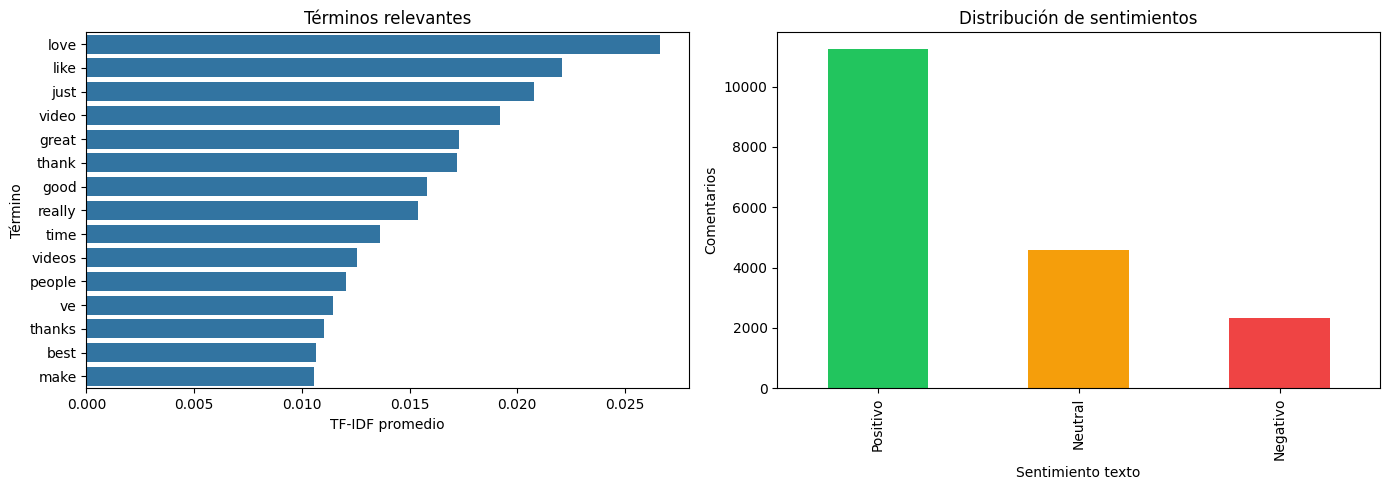

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

corpus_comentarios = comentarios_limpios["Comment"].astype(str)

vectorizador_mineria = TfidfVectorizer(
    stop_words="english", max_features=2000, min_df=3
)
matriz_tfidf_mineria = vectorizador_mineria.fit_transform(corpus_comentarios)
promedios = np.asarray(matriz_tfidf_mineria.mean(axis=0)).ravel()
terminos = vectorizador_mineria.get_feature_names_out()
top_terminos = pd.DataFrame({"Término": terminos, "TF-IDF promedio": promedios}).nlargest(
    15, "TF-IDF promedio"
)

vectorizador_bigramas = CountVectorizer(
    stop_words="english", ngram_range=(2, 2), max_features=2000, min_df=3
)
matriz_bigramas = vectorizador_bigramas.fit_transform(corpus_comentarios)
frecuencias_bigramas = np.asarray(matriz_bigramas.sum(axis=0)).ravel()
top_bigramas = pd.DataFrame({
    "Bigrama": vectorizador_bigramas.get_feature_names_out(),
    "Frecuencia": frecuencias_bigramas
}).nlargest(15, "Frecuencia")

display(top_terminos)
display(top_bigramas)

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=top_terminos, x="TF-IDF promedio", y="Término", ax=ejes[0])
ejes[0].set_title("Términos relevantes")
comentarios_limpios["Sentimiento texto"].value_counts().plot.bar(ax=ejes[1], color=["#22c55e", "#f59e0b", "#ef4444"])
ejes[1].set_title("Distribución de sentimientos")
ejes[1].set_ylabel("Comentarios")
plt.tight_layout()
plt.show()

## 📈 18. Predicción del desempeño de videos

Se estima `log(visualizaciones + 1)` utilizando exclusivamente características obtenidas de los comentarios. Se compara un modelo base con Random Forest. El ejercicio muestra asociación predictiva, no causalidad.

,Modelo,MAE,RMSE,R2
0,Línea base,1.9660,2.4168,-0.0062
1,Random Forest,1.2343,1.6314,0.5415


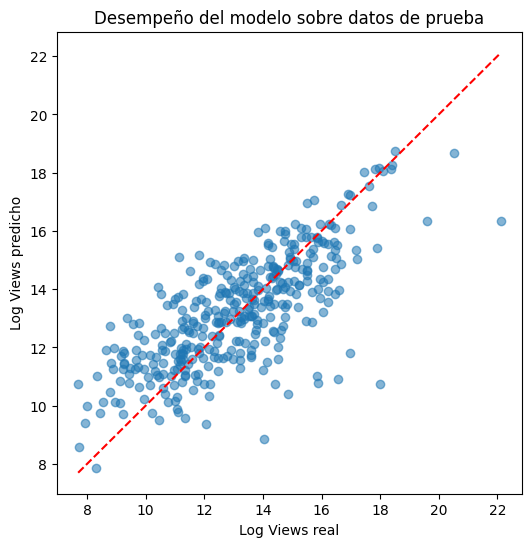

In [14]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

variables_comentarios = [
    "Comentarios_disponibles",
    "Likes_comentarios_total",
    "Likes_comentarios_promedio",
    "Palabras_promedio",
    "Caracteres_promedio",
    "Sentimiento_promedio",
    "Proporcion_negativos",
    "Proporcion_neutrales",
    "Proporcion_positivos"
]

datos_modelo = datos_youtube.dropna(
    subset=variables_comentarios + ["Log_Views"]
).copy()
X_modelo = datos_modelo[variables_comentarios]
y_modelo = datos_modelo["Log_Views"]

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_modelo, y_modelo, test_size=0.20, random_state=42
)

modelo_base = DummyRegressor(strategy="median").fit(X_train_v, y_train_v)
modelo_desempeno = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
).fit(X_train_v, y_train_v)

def evaluar_regresion(nombre, reales, predichos):
    return {
        "Modelo": nombre,
        "MAE": mean_absolute_error(reales, predichos),
        "RMSE": np.sqrt(mean_squared_error(reales, predichos)),
        "R2": r2_score(reales, predichos)
    }

pred_base = modelo_base.predict(X_test_v)
pred_rf = modelo_desempeno.predict(X_test_v)
metricas_modelo = pd.DataFrame([
    evaluar_regresion("Línea base", y_test_v, pred_base),
    evaluar_regresion("Random Forest", y_test_v, pred_rf)
]).round(4)
display(metricas_modelo)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_v, pred_rf, alpha=0.55)
limites = [min(y_test_v.min(), pred_rf.min()), max(y_test_v.max(), pred_rf.max())]
plt.plot(limites, limites, "r--")
plt.xlabel("Log Views real")
plt.ylabel("Log Views predicho")
plt.title("Desempeño del modelo sobre datos de prueba")
plt.show()

## 🧪 Registro y persistencia MLOps

Se guardan el modelo, las variables y las métricas con fecha de ejecución para mantener trazabilidad del experimento.

In [15]:
carpeta_artefactos = Path("artefactos_nlp")
carpeta_artefactos.mkdir(exist_ok=True)

joblib.dump(modelo_desempeno, carpeta_artefactos / "modelo_youtube.joblib")
metricas_modelo.to_csv(carpeta_artefactos / "metricas_modelo.csv", index=False)

metadatos = {
    "fecha_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": "advaypatil/youtube-statistics",
    "filas_entrenamiento": int(len(X_train_v)),
    "filas_prueba": int(len(X_test_v)),
    "variables": variables_comentarios,
    "semilla": 42
}
with (carpeta_artefactos / "metadatos.json").open("w", encoding="utf-8") as archivo:
    json.dump(metadatos, archivo, ensure_ascii=False, indent=2)

print("Artefactos guardados en:", carpeta_artefactos.resolve())
print([ruta.name for ruta in carpeta_artefactos.iterdir()])

Artefactos guardados en: /content/artefactos_nlp
['modelo_youtube.joblib', 'metricas_modelo.csv', 'metadatos.json']


## 🖥️ Interfaz consumible con Gradio

La interfaz recibe las características agregadas de los comentarios y devuelve una estimación de visualizaciones. Al ejecutarla en Colab puede generarse un enlace temporal con `share=True`.

In [18]:
import gradio as gr

def predecir_visualizaciones(*valores):
    entrada = pd.DataFrame([valores], columns=variables_comentarios)
    log_predicho = modelo_desempeno.predict(entrada)[0]
    return int(max(0, np.expm1(log_predicho)))

entradas_gradio = [
    gr.Number(label=variable, value=float(datos_modelo[variable].median()))
    for variable in variables_comentarios
]

demo = gr.Interface(
    fn=predecir_visualizaciones,
    inputs=entradas_gradio,
    outputs=gr.Number(label="Visualizaciones estimadas"),
    title="Predicción experimental de desempeño en YouTube",
    description="Estimación basada exclusivamente en características agregadas de comentarios."
)

print("Interfaz preparada. Ejecuta demo.launch(share=True) cuando quieras probarla.")
demo.launch(share=True)

Interfaz preparada. Ejecuta demo.launch(share=True) cuando quieras probarla.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45c705d9790785ef25.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## ✅ Conclusiones del tercer bloque

- Se aplicaron Question Answering, Summarization, Sentence Similarity, Text Classification, Translation, Text Generation y Text Mining.
- Los comentarios se transformaron en características numéricas para estimar el desempeño de los videos.
- La comparación contra una línea base permite determinar si Random Forest aporta capacidad predictiva real.
- Los resultados representan asociaciones sobre un conjunto histórico; no demuestran que el sentimiento cause más visualizaciones.
- El modelo, las métricas y los metadatos quedan almacenados como artefactos reproducibles y se ofrece una interfaz de consumo con Gradio.